In [1]:
import sys
from pathlib import Path


sys.path.append(str(Path().absolute().parent))


In [ ]:
import pytorch_lightning as pl
from pytorch_lightning.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    LearningRateMonitor,
)
from torch.nn import MSELoss
from torch.optim import Adam
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns

import pandas as pd
from pathlib import Path


from src.data_models.caravanify import Caravanify, CaravanifyConfig

from src.data_models.datamodule import HydroDataModule

from sklearn.pipeline import Pipeline

from src.preprocessing.grouped import GroupedTransformer
# from src.preprocessing.log_scale import LogTransformer
from src.preprocessing.standard_scale import StandardScaleTransformer

from src.model_evaluation.evaluators import TSForecastEvaluator
from src.models.tsmixer import TSMixerConfig, LitTSMixer

---

In [3]:
config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/shapefiles",
    human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="CA",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)


caravan = Caravanify(config)
ids_for_training = caravan.get_all_gauge_ids()[:5]

path_to_hii = "/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv"

# ids_for_training, _ = caravan.filter_gauge_ids_by_human_influence(
#     ids_for_training, ["Low", "Medium"]
# )

caravan.load_stations(ids_for_training)
static_data = caravan.get_static_attributes()
ts_data = caravan.get_time_series()

In [4]:
ts_columns = [
    # "potential_evaporation_sum_FAO_PENMAN_MONTEITH",
    "streamflow",
    # "temperature_2m_mean",
    # "total_precipitation_sum",
]

ts_columns_to_keep = ts_columns + ["gauge_id", "date"]
ts_data = ts_data[ts_columns_to_keep]

In [5]:
static_columns = [
    "p_mean",
    "area",
    "ele_mt_sav",
    "high_prec_dur",
    "frac_snow",
    "high_prec_freq",
    "slp_dg_sav",
    "cly_pc_sav",
    "aridity_ERA5_LAND",
    "aridity_FAO_PM",
]

static_columns_to_keep = static_columns + ["gauge_id"]

static_data = static_data[static_columns_to_keep]

In [6]:
forcing_features = [
    col for col in ts_columns if col not in ["gauge_id", "date", "streamflow"]
]

target_feature = "streamflow"

---

In [7]:
feature_pipeline = Pipeline(
    [
        # ("log", LogTransformer(columns=dynamic_feature_cols)),
        ("scaler", StandardScaleTransformer(columns=forcing_features)),
    ]
)

# Target pipeline: grouped by basin with log + scale
target_pipeline = GroupedTransformer(
    Pipeline(
        [
            # ("log", LogTransformer(columns=target_cols)),
            ("scaler", StandardScaleTransformer(columns=[target_feature])),
        ]
    ),
    columns=[target_feature],
    group_identifier="gauge_id",
    n_jobs=-1,
)

# Static feature pipeline: just scaling
static_pipeline = Pipeline(
    [("scaler", StandardScaleTransformer(columns=static_columns))]
)

# Define preprocessing configurations
preprocessing_configs = {
    "features": {"pipeline": feature_pipeline, "columns": ts_columns},
    "target": {"pipeline": target_pipeline, "columns": [target_feature]},
    "static_features": {"pipeline": static_pipeline, "columns": static_columns},
}

---

In [8]:
output_length = 10
input_length = 40

data_module = HydroDataModule(
    time_series_df=ts_data,
    static_df=static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_configs,
    batch_size=256,
    input_length=input_length,
    output_length=output_length,
    num_workers=4,
    features=ts_columns,
    static_features=static_columns,
    target="streamflow",
    train_prop=0.5,
    val_prop=0.25,
    test_prop=0.25,
    use_proportional_split=True,
    max_imputation_gap_size=2,
    min_train_years=2
    
)

data_module.prepare_data()
data_module.setup(stage="fit")

Original basins: 5
Retained basins: 5
Domain training (source): Created 19979 valid sequences from 5 catchments
Domain training (source): Created 9865 valid sequences from 5 catchments


In [9]:
# quality_report = data_module.quality_report
# quality_report["processing_steps"]

---

In [10]:
config = TSMixerConfig(
    input_len=input_length,
    output_len=output_length,
    input_size=len(ts_columns),
    static_size=len(static_columns),
    hidden_size=30,
    future_input_size=len(ts_columns) - 1,
    learning_rate=7e-4,
    dropout=0.1,
    num_mixing_layers=2,  # changed from num_layers
)
model = LitTSMixer(config)

trainer = pl.Trainer(
    max_epochs=1,
    accelerator="cpu",
    devices=1,
    callbacks=[
        ModelCheckpoint(
            monitor="val_loss",
            dirpath="checkpoints",
            filename="best-checkpoint",
            save_top_k=1,
            mode="min",
        ),
        EarlyStopping(monitor="val_loss", patience=3, mode="min"),
        LearningRateMonitor(logging_interval="epoch"),
    ],
)

# Train the model
trainer.fit(model, data_module)

/Users/cooper/Desktop/CAMELS-CH/.venv/lib/python3.12/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/cooper/Desktop/CAMELS-CH/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Original basins: 5
Retained basins: 5


/Users/cooper/Desktop/CAMELS-CH/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /Users/cooper/Desktop/CAMELS-CH/notebooks/checkpoints exists and is not empty.

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | mse_criterion | MSELoss | 0      | train
1 | model         | TSMixer | 19.3 K | train
--------------------------------------------------
19.3 K    Trainable params
0         Non-trainable params
19.3 K    Total params
0.077     Total estimated model params size (MB)
66        Modules in train mode
0         Modules in eval mode


Domain training (source): Created 19979 valid sequences from 5 catchments
Domain training (source): Created 9865 valid sequences from 5 catchments


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.


---

In [11]:
models_and_datamodules = {
    "TSMixer": (model, data_module),
}

evaluator = TSForecastEvaluator(
    horizons=list(range(1, 11)),
    models_and_datamodules=models_and_datamodules,  
    trainer_kwargs={"accelerator": "cpu", "devices": 1},
)

In [12]:
results = evaluator.test_models()

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Testing TSMixer...


/Users/cooper/Desktop/CAMELS-CH/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Original basins: 5
Retained basins: 5
Domain training (source): Created 9876 valid sequences from 5 catchments


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.5784925818443298
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Evaluating results with shape: preds=(9876, 10), obs=(9876, 10), basin_ids=(9876,)


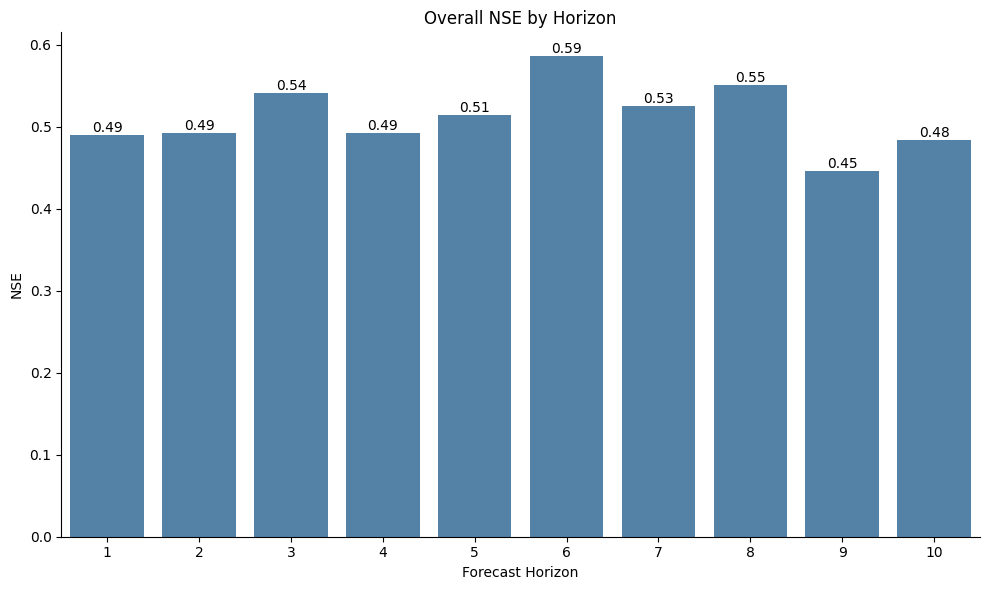

In [13]:
overall_summary = evaluator.summarize_metrics(results["TSMixer"]["metrics"])

def plot_metric_summary(
    summary_df: pd.DataFrame, metric: str, per_basin: bool = False, figsize=(10, 6)
):
    plt.figure(figsize=figsize)

    if per_basin:
        df_plot = summary_df[metric].unstack(level=0)

        # Sort basins based on first horizon values
        first_horizon_values = df_plot.iloc[0]
        sorted_basins = first_horizon_values.sort_values(ascending=False).index
        df_plot = df_plot[sorted_basins]

        sns.barplot(
            data=df_plot.melt(ignore_index=False).reset_index(),
            x="horizon",
            y="value",
            hue="basin_id",
            palette="Blues",
        )
        plt.title(f"{metric} by Basin and Horizon")
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Basin ID")

    else:
        ax = sns.barplot(x=summary_df.index, y=summary_df[metric], color="steelblue")
        plt.title(f"Overall {metric} by Horizon")

        for i, v in enumerate(summary_df[metric]):
            ax.text(i, v, f"{v:.2f}", ha="center", va="bottom")

    plt.xlabel("Forecast Horizon")
    plt.ylabel(metric)
    plt.tight_layout()
    sns.despine()
    plt.show()


 # Plot overall NSE
plot_metric_summary(
    overall_summary,
    metric="NSE",
    per_basin=False,
    figsize=(10, 6),
)

In [14]:
# evaluator.plot_rolling_forecast(
#     "TSMixer",
#     horizon=10, 
#     group_identifier="CA_15013"
# )

In [15]:
results["TSMixer"]["df"]

,horizon,prediction,observed,basin_id,date
0,1,5.126509,8.13,CA_15013,2017-05-10
1,2,5.268033,6.80,CA_15013,2017-05-11
2,3,5.045094,6.10,CA_15013,2017-05-12
3,4,5.009215,6.33,CA_15013,2017-05-13
4,5,5.456970,6.56,CA_15013,2017-05-14
...,...,...,...,...,...
98755,6,5.007924,4.03,CA_15025,2022-07-27
98756,7,4.634322,3.98,CA_15025,2022-07-28
98757,8,4.876273,4.59,CA_15025,2022-07-29
98758,9,5.294940,4.46,CA_15025,2022-07-30


In [16]:
results["TSMixer"].keys()

dict_keys(['df', 'metrics', 'basin_metrics', 'datamodule'])

In [23]:
dm = results["TSMixer"]["basin_metrics"]
dm

{'CA_15013': {1: {'MSE': np.float32(0.9156108),
   'MAE': np.float32(0.635057),
   'NSE': np.float32(0.67567396),
   'RMSE': np.float32(0.95687556)},
  2: {'MSE': np.float32(0.9177515),
   'MAE': np.float32(0.6407797),
   'NSE': np.float32(0.6729191),
   'RMSE': np.float32(0.95799345)},
  3: {'MSE': np.float32(0.9373308),
   'MAE': np.float32(0.615909),
   'NSE': np.float32(0.66472846),
   'RMSE': np.float32(0.9681584)},
  4: {'MSE': np.float32(0.97605747),
   'MAE': np.float32(0.61093044),
   'NSE': np.float32(0.6499883),
   'RMSE': np.float32(0.9879562)},
  5: {'MSE': np.float32(1.0809983),
   'MAE': np.float32(0.67353153),
   'NSE': np.float32(0.6112357),
   'RMSE': np.float32(1.0397106)},
  6: {'MSE': np.float32(0.9180597),
   'MAE': np.float32(0.6443751),
   'NSE': np.float32(0.6687566),
   'RMSE': np.float32(0.9581543)},
  7: {'MSE': np.float32(1.095396),
   'MAE': np.float32(0.7117935),
   'NSE': np.float32(0.60254455),
   'RMSE': np.float32(1.0466117)},
  8: {'MSE': np.float32(

---